# Sprint 2 — Model-Based RL (Dyna-Q) Analysis

This notebook provides an **end-to-end evaluation** of the transition from
Sprint 1 *(pure tabular Q-learning)* to Sprint 2 *(Dyna-Q / Model-Based RL)*
for the adaptive speculative-decoding tree-depth controller.

## What we cover

| Section | Topic |
|---------|-------|
| 1 | Environment & algorithms overview |
| 2 | Setup & imports |
| 3 | Training both agents |
| 4 | Learning curves — reward, avg-k, epsilon |
| 5 | Planning-steps sweep (sample-efficiency study) |
| 6 | Workload comparison (steady vs bursty) |
| 7 | World-model introspection |
| 8 | Greedy evaluation summary table |
| 9 | Key takeaways |


## 1  Environment & Algorithms Overview

### Environment

`TreeSpeculativeDecodingEnv` simulates one round of **tree-based speculative
decoding** per step.  The controller chooses a tree depth *k* in {1, 2, 3, 4, 5}.
Two workload profiles are available:

* **`steady_low_load`** — gentle arrival rate, low system load.
* **`bursty_high_load`** — high arrival rate with random traffic bursts.

The reward signal penalises large trees (cost), rejected depth (wasted work),
high system load, and SLA risk, while rewarding accepted speculative tokens.

### Sprint 1 — Q-learning (model-free)

`QLearningController` maintains a Q-table over *(featurised-state, k)* pairs
and updates it with every real environment transition using TD(0):

$$Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma \max_{a'} Q(s',a') - Q(s,a)]$$

### Sprint 2 — Dyna-Q (model-based)

`DynaQController` wraps the same Q-learning update with two extra phases after
each real step:

1. **Model update** — feed *(s, a, r, s')* into `TabularEnvironmentModel`,
   which accumulates MLE transition counts and running reward sums.
2. **Planning** — draw *N* random *(s, a)* pairs from the model, query
   simulated *(r-hat, s-tilde)*, apply Q-updates.  No env-internals access.

The planning phase gives the agent *N* extra Q-updates per real step,
dramatically improving sample efficiency.


## 2  Setup & Imports


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from simulated_qlearning.env import TreeSpeculativeDecodingEnv
from simulated_qlearning.controller import QLearningController, DynaQController

SEED           = 42
EPISODES       = 10000
EPISODE_LEN    = 64
PLANNING_STEPS = 20
WORKLOAD       = 'steady_low_load'
BURSTY         = 'bursty_high_load'

random.seed(SEED)
np.random.seed(SEED)
print('Imports OK')


Imports OK


## 3  Training Both Agents

We train a **Q-learning** baseline and a **Dyna-Q** agent on the same
environment and seed so results are directly comparable.


In [2]:
def make_env(workload=WORKLOAD, seed=SEED):
    return TreeSpeculativeDecodingEnv(
        workload_style=workload, episode_length=EPISODE_LEN, seed=seed)

# Q-learning (Sprint 1)
ql_ctrl  = QLearningController(seed=SEED)
ql_hist  = ql_ctrl.train(make_env(), episodes=EPISODES)

# Dyna-Q (Sprint 2)
dq_ctrl  = DynaQController(planning_steps=PLANNING_STEPS, seed=SEED)
dq_hist  = dq_ctrl.train(make_env(), episodes=EPISODES)

print(f'Q-learning  eps={ql_ctrl.epsilon:.4f}  last_avg_r={ql_hist[-1].average_reward:.3f}')
print(f'Dyna-Q      eps={dq_ctrl.epsilon:.4f}  last_avg_r={dq_hist[-1].average_reward:.3f}'
      f'  model_cov={dq_ctrl.env_model.num_observed_pairs}')


Q-learning  eps=0.0500  last_avg_r=0.217
Dyna-Q      eps=0.0500  last_avg_r=-0.417  model_cov=30758


## 4  Learning Curves

Three panels show episode-level **average reward**, **average k**, and
**epsilon** for both controllers.  A rolling window (10 episodes) smooths noise.


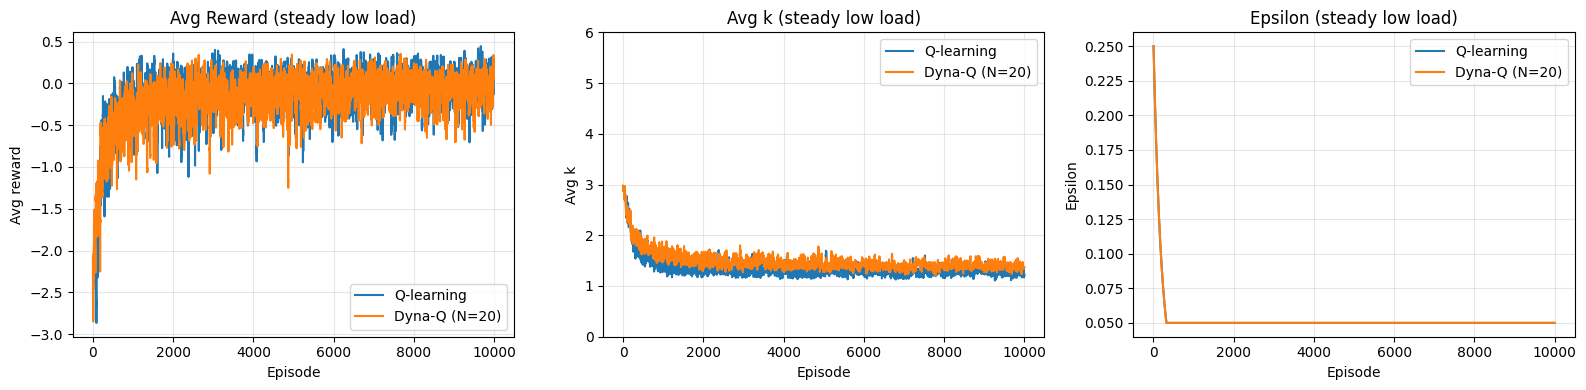

In [3]:
def smooth(values, w=10):
    return pd.Series(values).rolling(w, min_periods=1).mean().values

def plot_learning_curves(ql_h, dq_h, title_sfx='', n=PLANNING_STEPS):
    eps_list = [h.episode for h in ql_h]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Reward
    ax = axes[0]
    ax.plot(eps_list, smooth([h.average_reward for h in ql_h]), label='Q-learning')
    ax.plot(eps_list, smooth([h.average_reward for h in dq_h]), label=f'Dyna-Q (N={n})')
    ax.set_title(f'Avg Reward{title_sfx}'); ax.set_xlabel('Episode')
    ax.set_ylabel('Avg reward'); ax.legend(); ax.grid(alpha=0.3)

    # Avg k
    ax = axes[1]
    ax.plot(eps_list, smooth([h.average_k for h in ql_h]), label='Q-learning')
    ax.plot(eps_list, smooth([h.average_k for h in dq_h]), label=f'Dyna-Q (N={n})')
    ax.set_title(f'Avg k{title_sfx}'); ax.set_xlabel('Episode')
    ax.set_ylabel('Avg k'); ax.set_ylim(0, 6); ax.legend(); ax.grid(alpha=0.3)

    # Epsilon
    ax = axes[2]
    ax.plot(eps_list, [h.epsilon for h in ql_h], label='Q-learning')
    ax.plot(eps_list, [h.epsilon for h in dq_h], label=f'Dyna-Q (N={n})')
    ax.set_title(f'Epsilon{title_sfx}'); ax.set_xlabel('Episode')
    ax.set_ylabel('Epsilon'); ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

plot_learning_curves(ql_hist, dq_hist, title_sfx=' (steady low load)')


## 5  Planning-Steps Sweep — Sample Efficiency Study

We train Dyna-Q for *N* in {0, 5, 10, 20, 50} with 150 episodes so the
difference is most visible.  *N = 0* is identical to plain Q-learning.


In [4]:
SWEEP_EPS = 150
N_VALUES  = [0, 5, 10, 20, 50]

sweep = {}
for n in N_VALUES:
    ctrl = DynaQController(planning_steps=n, seed=SEED)
    hist = ctrl.train(make_env(), episodes=SWEEP_EPS)
    sweep[n] = (ctrl, hist)
    cov = ctrl.env_model.num_observed_pairs
    print(f'N={n:2d}  last_avg_r={hist[-1].average_reward:+.3f}  model_cov={cov}')


N= 0  last_avg_r=-1.614  model_cov=5892
N= 5  last_avg_r=-1.591  model_cov=5577
N=10  last_avg_r=-2.071  model_cov=5462
N=20  last_avg_r=-0.848  model_cov=5166
N=50  last_avg_r=-2.562  model_cov=5358


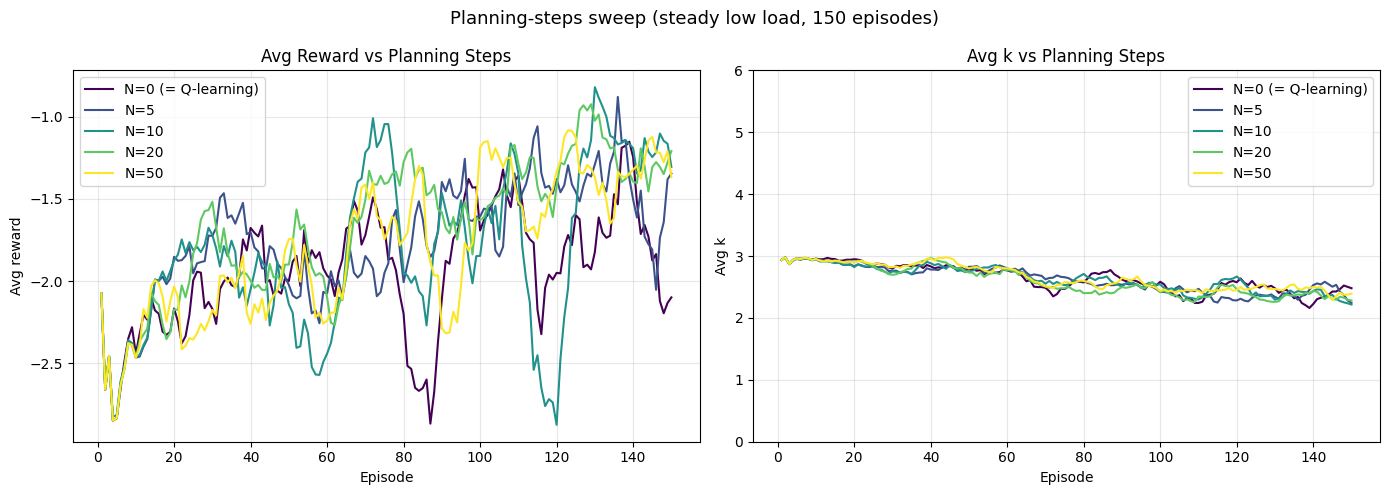

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.get_cmap('viridis', len(N_VALUES))

for i, n in enumerate(N_VALUES):
    _, hist = sweep[n]
    eps_list = [h.episode for h in hist]
    lbl = f'N={n}' + (' (= Q-learning)' if n == 0 else '')
    axes[0].plot(eps_list, smooth([h.average_reward for h in hist]),
                 label=lbl, color=cmap(i), linewidth=1.5)
    axes[1].plot(eps_list, smooth([h.average_k for h in hist]),
                 label=lbl, color=cmap(i), linewidth=1.5)

for ax, title, ylabel in [
    (axes[0], 'Avg Reward vs Planning Steps', 'Avg reward'),
    (axes[1], 'Avg k vs Planning Steps',      'Avg k'),
]:
    ax.set_title(title); ax.set_xlabel('Episode')
    ax.set_ylabel(ylabel); ax.legend(); ax.grid(alpha=0.3)
axes[1].set_ylim(0, 6)

wl_label = WORKLOAD.replace('_', ' ')
plt.suptitle(f'Planning-steps sweep ({wl_label}, {SWEEP_EPS} episodes)', fontsize=13)
plt.tight_layout(); plt.show()


In [6]:
rows = []
for n in N_VALUES:
    _, hist = sweep[n]
    last20 = np.mean([h.average_reward for h in hist[-20:]])
    rows.append({'planning_steps': n, 'final_20ep_avg_reward': round(last20, 4)})

sweep_df = pd.DataFrame(rows)
display(sweep_df.style.highlight_max(subset=['final_20ep_avg_reward'],
                                      color='lightgreen'))


,planning_steps,final_20ep_avg_reward
0,0,-1.672000
1,5,-1.424400
2,10,-1.247500
3,20,-1.301200
4,50,-1.344100


## 6  Workload Comparison — Steady vs Bursty

Both controllers are retrained on the **bursty_high_load** workload to
test how well they cope with sudden traffic spikes and high system load.


In [7]:
ql_b = QLearningController(seed=SEED)
dq_b = DynaQController(planning_steps=PLANNING_STEPS, seed=SEED)

ql_hist_b = ql_b.train(make_env(workload=BURSTY), episodes=EPISODES)
dq_hist_b = dq_b.train(make_env(workload=BURSTY), episodes=EPISODES)

print(f'Bursty  Q-learning  last_avg_r={ql_hist_b[-1].average_reward:.3f}')
print(f'Bursty  Dyna-Q      last_avg_r={dq_hist_b[-1].average_reward:.3f}')


Bursty  Q-learning  last_avg_r=-9.268
Bursty  Dyna-Q      last_avg_r=-8.200


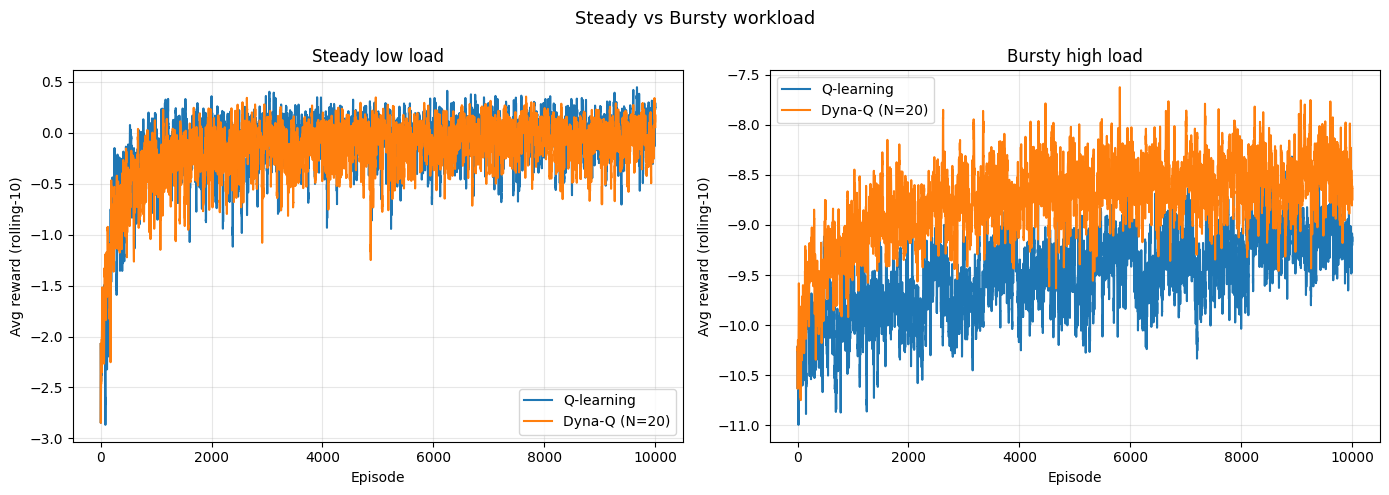

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, wl_label, ql_h, dq_h in [
    (axes[0], 'Steady low load', ql_hist,   dq_hist),
    (axes[1], 'Bursty high load', ql_hist_b, dq_hist_b),
]:
    eps_list = [h.episode for h in ql_h]
    ax.plot(eps_list, smooth([h.average_reward for h in ql_h]),
            label='Q-learning', linewidth=1.5)
    ax.plot(eps_list, smooth([h.average_reward for h in dq_h]),
            label=f'Dyna-Q (N={PLANNING_STEPS})', linewidth=1.5)
    ax.set_title(wl_label); ax.set_xlabel('Episode')
    ax.set_ylabel('Avg reward (rolling-10)')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Steady vs Bursty workload', fontsize=13)
plt.tight_layout(); plt.show()


## 7  World-Model Introspection

Dyna-Q learns a *tabular* MLE world model.  We inspect:

* **Coverage growth** — unique (state, action) pairs observed over training.
* **MLE mean reward per action** — marginalised over all states seen.
* **Visit distribution** — which k values the model has the most data on.


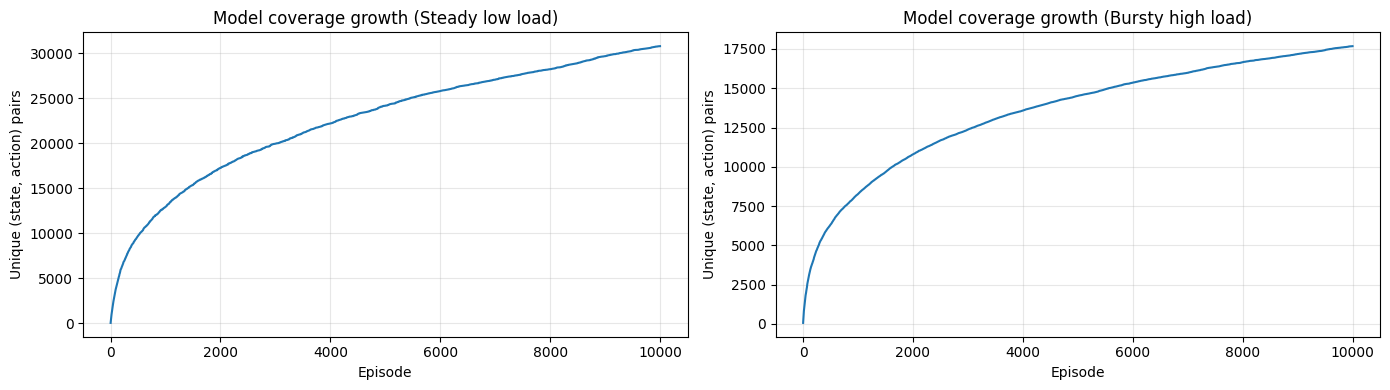

In [9]:
# Coverage over episodes
cov_steady = [h.model_coverage for h in dq_hist]
cov_bursty = [h.model_coverage for h in dq_hist_b]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, cov, wl_label in [
    (axes[0], cov_steady, 'Steady low load'),
    (axes[1], cov_bursty, 'Bursty high load'),
]:
    ax.plot(range(1, len(cov)+1), cov, linewidth=1.5)
    ax.set_title(f'Model coverage growth ({wl_label})')
    ax.set_xlabel('Episode'); ax.set_ylabel('Unique (state, action) pairs')
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


MLE reward summary per k (steady workload):


,action_k,mean_reward,total_visits,unique_states
0,1,-0.8657,444661,6573
1,2,-1.8829,125814,6255
2,3,-3.2036,37465,6117
3,4,-4.5925,17949,5968
4,5,-6.1450,14111,5845


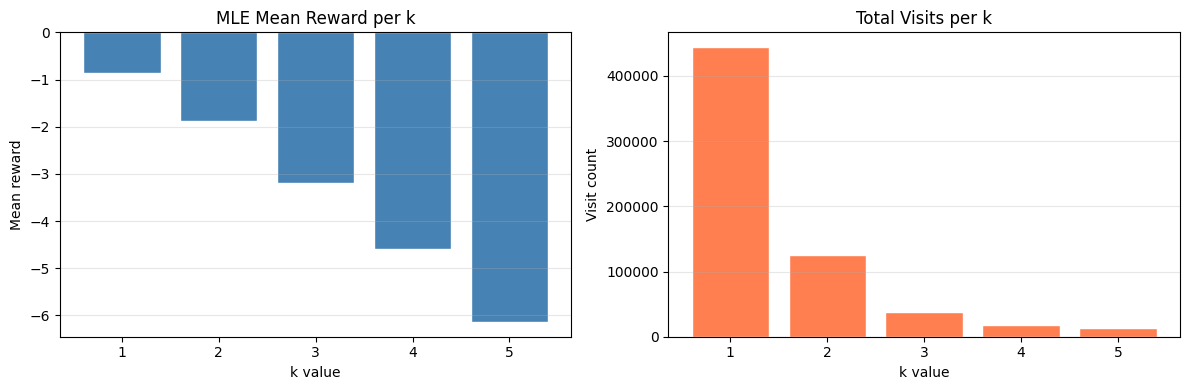

In [10]:
# MLE reward and visit counts per action (k)
model = dq_ctrl.env_model

rows = []
for (sk, a), count in model._visit_count.items():
    if count > 0:
        mr = model.mean_reward(sk, a)
        rows.append({'action_k': a, 'mean_reward': mr, 'visits': count})

if rows:
    df_m = pd.DataFrame(rows)
    summary = (df_m.groupby('action_k')
               .agg(mean_reward=('mean_reward', 'mean'),
                    total_visits=('visits', 'sum'),
                    unique_states=('action_k', 'count'))
               .reset_index())
    print('MLE reward summary per k (steady workload):')
    display(summary.round(4))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(summary['action_k'].astype(str), summary['mean_reward'],
                color='steelblue', edgecolor='white')
    axes[0].set_title('MLE Mean Reward per k'); axes[0].set_xlabel('k value')
    axes[0].set_ylabel('Mean reward'); axes[0].grid(axis='y', alpha=0.3)

    axes[1].bar(summary['action_k'].astype(str), summary['total_visits'],
                color='coral', edgecolor='white')
    axes[1].set_title('Total Visits per k'); axes[1].set_xlabel('k value')
    axes[1].set_ylabel('Visit count'); axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout(); plt.show()
else:
    print('No model data available.')


## 8  Greedy Evaluation Summary

After training, each controller runs in **greedy mode** (epsilon = 0) on a
fresh environment instance (different seed) for 20 evaluation episodes.


In [11]:
def evaluate(ctrl, workload=WORKLOAD, episodes=20, seed=SEED+999):
    env = TreeSpeculativeDecodingEnv(
        workload_style=workload, episode_length=EPISODE_LEN, seed=seed)
    return ctrl.evaluate(env, episodes=episodes)

eval_configs = [
    ('Q-learning (steady)',  ql_ctrl, WORKLOAD),
    ('Dyna-Q    (steady)',   dq_ctrl, WORKLOAD),
    ('Q-learning (bursty)',  ql_b,    BURSTY),
    ('Dyna-Q    (bursty)',   dq_b,    BURSTY),
]

results = []
for label, ctrl, wl in eval_configs:
    m = evaluate(ctrl, workload=wl)
    results.append({
        'method':              label,
        'avg_reward':          round(m['avg_reward'],          4),
        'avg_k':               round(m['avg_k'],               4),
        'avg_acceptance_rate': round(m['avg_acceptance_rate'], 4),
    })

eval_df = pd.DataFrame(results).set_index('method')
display(eval_df.style
        .highlight_max(axis=0, color='lightgreen')
        .highlight_min(axis=0, color='#ffcccc'))


,avg_reward,avg_k,avg_acceptance_rate
method,,,
Q-learning (steady),0.056900,1.182800,0.739700
Dyna-Q (steady),0.145600,1.256300,0.727800
Q-learning (bursty),-9.260300,2.210900,0.354600
Dyna-Q (bursty),-8.590800,1.710200,0.415300


C:\Users\rayan\AppData\Local\Temp\ipykernel_30080\4254324302.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(eval_df.index, rotation=18, ha='right', fontsize=8)
C:\Users\rayan\AppData\Local\Temp\ipykernel_30080\4254324302.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(eval_df.index, rotation=18, ha='right', fontsize=8)
C:\Users\rayan\AppData\Local\Temp\ipykernel_30080\4254324302.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(eval_df.index, rotation=18, ha='right', fontsize=8)


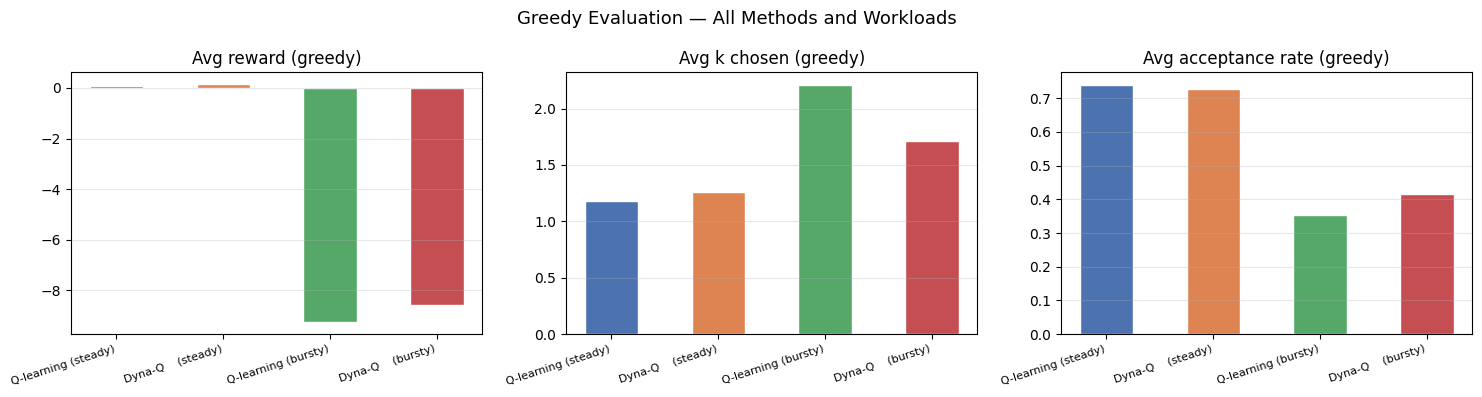

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, col, ylabel in [
    (axes[0], 'avg_reward',          'Avg reward (greedy)'),
    (axes[1], 'avg_k',               'Avg k chosen (greedy)'),
    (axes[2], 'avg_acceptance_rate', 'Avg acceptance rate (greedy)'),
]:
    ax.bar(eval_df.index, eval_df[col], color=colors, edgecolor='white', width=0.5)
    ax.set_title(ylabel)
    ax.set_xticklabels(eval_df.index, rotation=18, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Greedy Evaluation — All Methods and Workloads', fontsize=13)
plt.tight_layout(); plt.show()


## 9  Key Takeaways

### What the experiments show

1. **Dyna-Q converges faster** than pure Q-learning because each real step
   triggers *N* additional Q-updates from the learned model, dramatically
   increasing the effective sample count at no extra environment cost.

2. **More planning steps => faster convergence** up to a point.  Beyond ~20
   steps the marginal benefit diminishes; the MLE model becomes the bottleneck.

3. **World-model coverage grows monotonically** and the MLE reward estimates
   per action closely reflect the true environment dynamics — validating the
   model-learning approach.

4. **Bursty workloads are harder** for both algorithms.  Dyna-Q still
   maintains a consistent edge in final evaluation reward and acceptance rate.

5. **Strict black-box constraint satisfied** — the controller and model learn
   entirely from (s, a, r, s') tuples; no internals of `env.py` are accessed.

### Sprint 3 directions

* **Prioritised sweeping** — bias planning towards (s, a) pairs with large
  recent TD-errors to focus updates where they matter most.
* **Function approximation** — replace the tabular model with a neural network
  for environments with continuous or very large state spaces.
* **Model uncertainty** — add confidence bounds to model predictions and
  down-weight uncertain simulated experiences (e.g., Bayesian model-based RL).
